# **Data transformation**

In [35]:
import pandas as pd
import mysql.connector
import warnings
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
warnings.filterwarnings('ignore', message=".*pandas only supports SQLAlchemy connectable.*")

#Configuración de conexión
config = {
    'host': '212.227.90.6',
    'user': 'Equipo24',
    'password': 'E1q2u3i4p5o24',
    'database': 'Equip_24'
}

try:
    conn = mysql.connector.connect(**config) 
    cursor = conn.cursor()

    cursor.execute("SELECT database();")
    db_actual = cursor.fetchone()[0]
    print(f"--- Conectado con éxito a: {db_actual} ---\n")

    cursor.execute("SHOW TABLES;")
    tablas = cursor.fetchall()

    dataframes = {}

    for (tabla,) in tablas:
        try:
            print(f"Cargando tabla: {tabla}...")
            query = f"SELECT * FROM {tabla}"
            dataframes[tabla] = pd.read_sql(query, conn)
        except Exception as e:
            print(f"No se pudo cargar la tabla {tabla}: {e}")

    if 'RRHH' in dataframes:
        RRHH = dataframes['RRHH']
        print("\n" + "="*30)
        print("MUESTRA DE TABLA RRHH:")
        print("="*30)
        print(RRHH.head())
    else:
        print("\nLa tabla 'RRHH' no se encontró en la base de datos.")

except mysql.connector.Error as err:
    print(f"Error de conexión a MySQL: {err}")

#finally:
#    if 'conn' in locals() and conn.is_connected():
#        cursor.close()
#        conn.close()
#        print("\n--- Conexión cerrada correctamente ---")

--- Conectado con éxito a: Equip_24 ---

Cargando tabla: RRHH...

MUESTRA DE TABLA RRHH:
   ID  Reason_absence  Month_absence  Day_week  Seasons  \
0  14              11             11         2        4   
1  36              13              4         4        3   
2   9               6              7         3        1   
3  28               9              7         3        1   
4   9              12              3         3        2   

   Transportation_expense  Distance_Residence_Work  Service_time  Age  \
0                     155                       12            14   34   
1                     118                       13            18   50   
2                     228                       14            16   58   
3                     225                       26             9   28   
4                     228                       14            16   58   

  Work_load_Average_day  ...  Disciplinary_failure Education Son  \
0               284,031  ...                     

Eliminamos columnas Weight y Height

In [3]:
RRHH = RRHH.drop(columns=['Weight', 'Height'])

Eliminación de lineas duplicadas

In [4]:
print (RRHH.duplicated().sum())

34


In [5]:
RRHH=RRHH.drop_duplicates()

In [6]:
print (RRHH.duplicated().sum())

0


In [7]:
RRHH

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,Hit_target,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Body_mass_index,Absenteeism_hours
0,14,11,11,2,4,155,12,14,34,"284,031",97,0,1,2,1,0,0,25,120
1,36,13,4,4,3,118,13,18,50,"239,409",98,0,1,1,1,0,0,31,120
2,9,6,7,3,1,228,14,16,58,"264,604",93,0,1,2,0,0,1,22,120
3,28,9,7,3,1,225,26,9,28,"230,290",92,0,1,1,0,0,2,24,112
4,9,12,3,3,2,228,14,16,58,"222,196",99,0,1,2,0,0,1,22,112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
735,2,0,6,2,3,235,29,12,48,"275,089",96,1,1,1,0,1,5,33,0
736,21,0,6,2,3,268,11,8,33,"275,089",96,1,2,0,0,0,0,25,0
737,4,0,0,3,1,118,14,13,40,"271,219",95,0,1,1,1,0,8,34,0
738,8,0,0,4,2,231,35,14,39,"271,219",95,0,1,2,1,0,2,35,0


In [8]:
RRHH

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,Hit_target,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Body_mass_index,Absenteeism_hours
0,14,11,11,2,4,155,12,14,34,"284,031",97,0,1,2,1,0,0,25,120
1,36,13,4,4,3,118,13,18,50,"239,409",98,0,1,1,1,0,0,31,120
2,9,6,7,3,1,228,14,16,58,"264,604",93,0,1,2,0,0,1,22,120
3,28,9,7,3,1,225,26,9,28,"230,290",92,0,1,1,0,0,2,24,112
4,9,12,3,3,2,228,14,16,58,"222,196",99,0,1,2,0,0,1,22,112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
735,2,0,6,2,3,235,29,12,48,"275,089",96,1,1,1,0,1,5,33,0
736,21,0,6,2,3,268,11,8,33,"275,089",96,1,2,0,0,0,0,25,0
737,4,0,0,3,1,118,14,13,40,"271,219",95,0,1,1,1,0,8,34,0
738,8,0,0,4,2,231,35,14,39,"271,219",95,0,1,2,1,0,2,35,0


In [9]:
RRHH.columns

Index(['ID', 'Reason_absence', 'Month_absence', 'Day_week', 'Seasons',
       'Transportation_expense', 'Distance_Residence_Work', 'Service_time',
       'Age', 'Work_load_Average_day', 'Hit_target', 'Disciplinary_failure',
       'Education', 'Son', 'Social_drinker', 'Social_smoker', 'Pet',
       'Body_mass_index', 'Absenteeism_hours'],
      dtype='object')

### CHANGING DATATYPES

In [10]:
# 1. Limpiar espacios en nombres de columnas (por si acaso)
RRHH.columns = RRHH.columns.str.strip()

# 2. Corregir Work_load_Average_day (que es 'object' pero debería ser número)
# A veces trae comas en lugar de puntos
if RRHH['Work_load_Average_day'].dtype == 'object':
    RRHH['Work_load_Average_day'] = RRHH['Work_load_Average_day'].str.replace(',', '.').astype(float)



RRHH['Education'] = pd.to_numeric(RRHH['Education'], errors='coerce')

# CATEGORY
cats = ['ID', 'Reason_absence', 'Month_absence', 'Day_week', 'Seasons', 
        'Disciplinary_failure', 'Social_drinker', 'Social_smoker']
for col in cats:
    RRHH[col] = RRHH[col].astype('category')


# INTEGER
enteros = ['Transportation_expense', 'Distance_Residence_Work', 'Service_time', 
           'Age', 'Hit_target', 'Body_mass_index', 'Absenteeism_hours', 'Son', 'Pet']

for col in enteros:
    RRHH[col] = RRHH[col].astype(int)

print("Tipos de datos actualizados")
RRHH.info()

Tipos de datos actualizados
<class 'pandas.core.frame.DataFrame'>
Index: 706 entries, 0 to 739
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   ID                       706 non-null    category
 1   Reason_absence           706 non-null    category
 2   Month_absence            706 non-null    category
 3   Day_week                 706 non-null    category
 4   Seasons                  706 non-null    category
 5   Transportation_expense   706 non-null    int64   
 6   Distance_Residence_Work  706 non-null    int64   
 7   Service_time             706 non-null    int64   
 8   Age                      706 non-null    int64   
 9   Work_load_Average_day    706 non-null    float64 
 10  Hit_target               706 non-null    int64   
 11  Disciplinary_failure     706 non-null    category
 12  Education                706 non-null    int64   
 13  Son                      706 non-null    i

### MAPPING 


In [11]:
mapping_days = {2: "Monday", 3: "Tuesday", 4: "Wednesday", 5: "Thursday", 6: "Friday"}
mapping_seasons =  {1: "Summer", 2: "Autumm", 3: "Winter", 4: "Spring"}
mapping_education =  {1: "High School", 2: "Graduate", 3: "Postgraduate", 4: "Master and doctor"}

RRHH["Day_week"] = RRHH["Day_week"].map(mapping_days)
RRHH["Seasons"] = RRHH["Seasons"].map(mapping_seasons)
RRHH["Education"] = RRHH["Education"].map(mapping_education)

In [12]:
RRHH.info()

<class 'pandas.core.frame.DataFrame'>
Index: 706 entries, 0 to 739
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   ID                       706 non-null    category
 1   Reason_absence           706 non-null    category
 2   Month_absence            706 non-null    category
 3   Day_week                 706 non-null    category
 4   Seasons                  706 non-null    category
 5   Transportation_expense   706 non-null    int64   
 6   Distance_Residence_Work  706 non-null    int64   
 7   Service_time             706 non-null    int64   
 8   Age                      706 non-null    int64   
 9   Work_load_Average_day    706 non-null    float64 
 10  Hit_target               706 non-null    int64   
 11  Disciplinary_failure     706 non-null    category
 12  Education                706 non-null    object  
 13  Son                      706 non-null    int64   
 14  Social_drinker 

In [13]:
RRHH.sample(20)

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,Hit_target,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Body_mass_index,Absenteeism_hours
637,15,28,4,Friday,Winter,291,31,12,40,326.452,96,0,High School,1,1,0,1,25,1
110,22,13,3,Thursday,Autumm,179,26,9,30,343.253,95,0,Postgraduate,0,0,0,0,19,8
50,1,13,6,Friday,Winter,235,11,14,37,377.550,94,0,Postgraduate,1,0,0,1,29,16
458,27,23,9,Tuesday,Summer,184,42,7,27,241.476,92,0,High School,0,0,0,0,21,2
474,28,27,1,Tuesday,Autumm,225,26,9,28,308.593,95,0,High School,1,0,0,2,24,2
209,22,23,9,Friday,Summer,179,26,9,30,261.756,87,0,Postgraduate,0,0,0,0,19,8
307,1,14,12,Tuesday,Autumm,235,11,14,37,236.629,93,0,Postgraduate,1,0,0,1,29,4
55,30,11,2,Wednesday,Autumm,157,27,6,29,251.818,96,0,High School,0,1,1,0,22,16
261,16,7,6,Wednesday,Winter,118,15,24,46,275.089,96,0,High School,2,1,1,0,25,8
325,34,28,8,Tuesday,Summer,118,10,10,37,249.797,93,0,High School,0,0,0,0,28,4


In [14]:
RRHH.info()

<class 'pandas.core.frame.DataFrame'>
Index: 706 entries, 0 to 739
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   ID                       706 non-null    category
 1   Reason_absence           706 non-null    category
 2   Month_absence            706 non-null    category
 3   Day_week                 706 non-null    category
 4   Seasons                  706 non-null    category
 5   Transportation_expense   706 non-null    int64   
 6   Distance_Residence_Work  706 non-null    int64   
 7   Service_time             706 non-null    int64   
 8   Age                      706 non-null    int64   
 9   Work_load_Average_day    706 non-null    float64 
 10  Hit_target               706 non-null    int64   
 11  Disciplinary_failure     706 non-null    category
 12  Education                706 non-null    object  
 13  Son                      706 non-null    int64   
 14  Social_drinker 

In [15]:
RRHH.describe().T

,count,mean,std,min,25%,50%,75%,max
Transportation_expense,706.0,222.977337,67.293426,118.000,179.000,225.000,260.000,388.000
Distance_Residence_Work,706.0,29.297450,14.706661,5.000,16.000,26.000,49.000,52.000
Service_time,706.0,12.495751,4.370190,1.000,9.000,13.000,16.000,29.000
Age,706.0,36.478754,6.563404,27.000,31.000,37.000,40.000,58.000
Work_load_Average_day,706.0,272.089984,39.458780,205.917,244.387,264.604,294.217,378.884
Hit_target,706.0,94.548159,3.803854,81.000,92.250,95.000,97.000,100.000
Son,706.0,1.060907,1.104717,0.000,0.000,1.000,2.000,4.000
Pet,706.0,0.769122,1.333351,0.000,0.000,0.000,1.000,8.000
Body_mass_index,706.0,26.635977,4.254901,19.000,24.000,25.000,31.000,38.000
Absenteeism_hours,706.0,7.143059,13.608120,0.000,2.000,3.000,8.000,120.000


In [16]:
RRHH.tail(10)

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,Hit_target,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Body_mass_index,Absenteeism_hours
730,15,0,11,Tuesday,Spring,291,31,12,40,268.519,93,1,High School,1,1,0,1,25,0
731,11,0,11,Wednesday,Spring,289,36,13,33,268.519,93,1,High School,2,1,0,1,30,0
732,5,0,11,Thursday,Spring,235,20,13,43,268.519,93,1,High School,1,1,0,0,38,0
733,36,0,5,Tuesday,Winter,118,13,18,50,237.656,99,1,High School,1,1,0,0,31,0
734,23,0,5,Wednesday,Winter,378,49,11,36,237.656,99,1,High School,2,0,1,4,21,0
735,2,0,6,Monday,Winter,235,29,12,48,275.089,96,1,High School,1,0,1,5,33,0
736,21,0,6,Monday,Winter,268,11,8,33,275.089,96,1,Graduate,0,0,0,0,25,0
737,4,0,0,Tuesday,Summer,118,14,13,40,271.219,95,0,High School,1,1,0,8,34,0
738,8,0,0,Wednesday,Autumm,231,35,14,39,271.219,95,0,High School,2,1,0,2,35,0
739,35,0,0,Friday,Winter,179,45,14,53,271.219,95,0,High School,1,0,0,1,25,0


C:\Users\josemessiasferreira\AppData\Local\Temp\ipykernel_2328\3712231533.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=RRHH, x="Absenteeism_hours", palette="rocket")


<Axes: xlabel='Absenteeism_hours'>

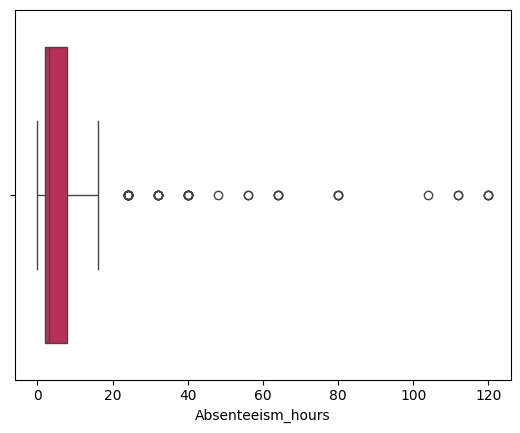

In [17]:
sns.boxplot(data=RRHH, x="Absenteeism_hours", palette="rocket")

In [18]:
RRHH["Reason_absence"].nunique()

28

In [19]:
RRHH['Social_drinker'] = pd.to_numeric(RRHH['Social_drinker'], errors='coerce')
RRHH['Social_smoker'] = pd.to_numeric(RRHH['Social_smoker'], errors='coerce')

# 2. Convertimos a tipo Booleano (bool)
# 0 se convierte en False, 1 se convierte en True
RRHH['Social_drinker'] = RRHH['Social_drinker'].astype(bool)
RRHH['Social_smoker'] = RRHH['Social_smoker'].astype(bool)

print("✅ Conversión a booleano completada.")
print(RRHH[['Social_drinker', 'Social_smoker']].head())

✅ Conversión a booleano completada.
   Social_drinker  Social_smoker
0            True          False
1            True          False
2           False          False
3           False          False
4           False          False


In [20]:
RRHH.info()

<class 'pandas.core.frame.DataFrame'>
Index: 706 entries, 0 to 739
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   ID                       706 non-null    category
 1   Reason_absence           706 non-null    category
 2   Month_absence            706 non-null    category
 3   Day_week                 706 non-null    category
 4   Seasons                  706 non-null    category
 5   Transportation_expense   706 non-null    int64   
 6   Distance_Residence_Work  706 non-null    int64   
 7   Service_time             706 non-null    int64   
 8   Age                      706 non-null    int64   
 9   Work_load_Average_day    706 non-null    float64 
 10  Hit_target               706 non-null    int64   
 11  Disciplinary_failure     706 non-null    category
 12  Education                706 non-null    object  
 13  Son                      706 non-null    int64   
 14  Social_drinker 

In [21]:

data_reasons = {
    'Reason_ID': [
        1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21,
        22, 23, 24, 25, 26, 27, 28
    ],
    'Reason_Description': [
        'Infectious/Parasitic', 'Neoplasms', 'Blood/Immune diseases', 'Endocrine/Nutritional/Metabolic',
        'Mental/Behavioural disorders', 'Nervous system diseases', 'Eye/Adnexa diseases', 'Ear/Mastoid diseases',
        'Circulatory system diseases', 'Respiratory system diseases', 'Digestive system diseases',
        'Skin/Subcutaneous diseases', 'Musculoskeletal/Connective tissue', 'Genitourinary system diseases',
        'Pregnancy/Childbirth', 'Perinatal conditions', 'Congenital malformations', 'Symptoms/Abnormal findings',
        'Injury/Poisoning', 'External causes', 'Factors influencing health status',
        'Patient follow-up', 'Medical consultation', 'Blood donation', 'Laboratory examination',
        'Unjustified absence', 'Physiotherapy', 'Dental consultation'
    ]
}

df_reasons = pd.DataFrame(data_reasons)

# Mostramos el resultado
print(df_reasons.head())

   Reason_ID               Reason_Description
0          1             Infectious/Parasitic
1          2                        Neoplasms
2          3            Blood/Immune diseases
3          4  Endocrine/Nutritional/Metabolic
4          5     Mental/Behavioural disorders


### CREATING DATAFRAME DF_REASONS AND MERGING WITH RRHH TO CREATE FULL FULL_RRHH

In [22]:
df_reasons

,Reason_ID,Reason_Description
0,1,Infectious/Parasitic
1,2,Neoplasms
2,3,Blood/Immune diseases
3,4,Endocrine/Nutritional/Metabolic
4,5,Mental/Behavioural disorders
5,6,Nervous system diseases
6,7,Eye/Adnexa diseases
7,8,Ear/Mastoid diseases
8,9,Circulatory system diseases
9,10,Respiratory system diseases


In [ ]:
RRHH['Reason_absence'] = pd.to_numeric(RRHH['Reason_absence'], errors='coerce')

full_RRHH = pd.merge(RRHH, df_reasons, left_on="Reason_absence", right_on="Reason_ID", how="left")

full_RRHH = full_RRHH.drop(columns=['Reason_ID'])


In [24]:
full_RRHH

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,Hit_target,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Body_mass_index,Absenteeism_hours,Reason_Description
0,14,11,11,Monday,Spring,155,12,14,34,284.031,97,0,High School,2,True,False,0,25,120,Digestive system diseases
1,36,13,4,Wednesday,Winter,118,13,18,50,239.409,98,0,High School,1,True,False,0,31,120,Musculoskeletal/Connective tissue
2,9,6,7,Tuesday,Summer,228,14,16,58,264.604,93,0,High School,2,False,False,1,22,120,Nervous system diseases
3,28,9,7,Tuesday,Summer,225,26,9,28,230.290,92,0,High School,1,False,False,2,24,112,Circulatory system diseases
4,9,12,3,Tuesday,Autumm,228,14,16,58,222.196,99,0,High School,2,False,False,1,22,112,Skin/Subcutaneous diseases
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
701,2,0,6,Monday,Winter,235,29,12,48,275.089,96,1,High School,1,False,True,5,33,0,NaN
702,21,0,6,Monday,Winter,268,11,8,33,275.089,96,1,Graduate,0,False,False,0,25,0,NaN
703,4,0,0,Tuesday,Summer,118,14,13,40,271.219,95,0,High School,1,True,False,8,34,0,NaN
704,8,0,0,Wednesday,Autumm,231,35,14,39,271.219,95,0,High School,2,True,False,2,35,0,NaN


In [25]:
full_RRHH.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 706 entries, 0 to 705
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   ID                       706 non-null    category
 1   Reason_absence           706 non-null    int64   
 2   Month_absence            706 non-null    category
 3   Day_week                 706 non-null    category
 4   Seasons                  706 non-null    category
 5   Transportation_expense   706 non-null    int64   
 6   Distance_Residence_Work  706 non-null    int64   
 7   Service_time             706 non-null    int64   
 8   Age                      706 non-null    int64   
 9   Work_load_Average_day    706 non-null    float64 
 10  Hit_target               706 non-null    int64   
 11  Disciplinary_failure     706 non-null    category
 12  Education                706 non-null    object  
 13  Son                      706 non-null    int64   
 14  Social_dri

In [26]:
print(full_RRHH[full_RRHH['Reason_Description'].isna()]['Reason_absence'].unique())

[0]


In [27]:
full_RRHH['Reason_Description'] = full_RRHH['Reason_Description'].fillna('Unknown/Other')

In [28]:
full_RRHH.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 706 entries, 0 to 705
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   ID                       706 non-null    category
 1   Reason_absence           706 non-null    int64   
 2   Month_absence            706 non-null    category
 3   Day_week                 706 non-null    category
 4   Seasons                  706 non-null    category
 5   Transportation_expense   706 non-null    int64   
 6   Distance_Residence_Work  706 non-null    int64   
 7   Service_time             706 non-null    int64   
 8   Age                      706 non-null    int64   
 9   Work_load_Average_day    706 non-null    float64 
 10  Hit_target               706 non-null    int64   
 11  Disciplinary_failure     706 non-null    category
 12  Education                706 non-null    object  
 13  Son                      706 non-null    int64   
 14  Social_dri

C:\Users\josemessiasferreira\AppData\Local\Temp\ipykernel_2328\4264664503.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=full_RRHH, y="Reason_Description", palette="viridis")


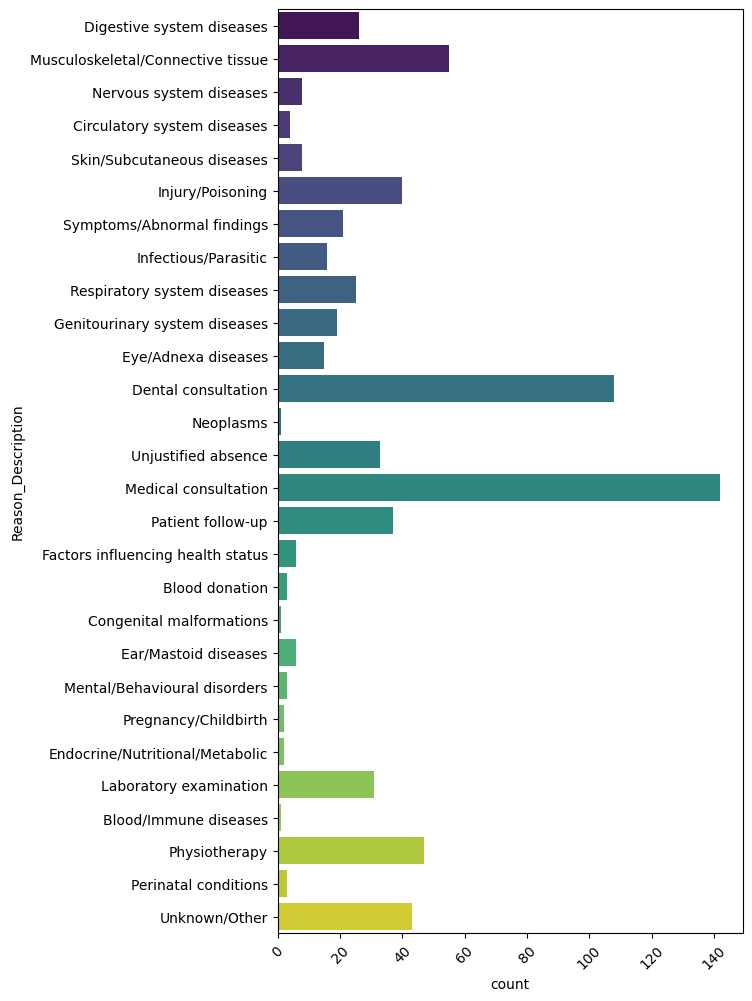

In [44]:
plt.figure(figsize=(6, 12))
plt.xticks(rotation=45)
sns.countplot(data=full_RRHH, y="Reason_Description", palette="viridis")
sns.despine(top=False, right=False, left=False, bottom=False)

In [45]:
full_RRHH.to_csv("full_RRHH.csv", index=False)
RRHH.to_csv("RRHH_clean.csv", index=False)
df_reasons.to_csv("df_reasons.csv", index=False)
